<a href="https://colab.research.google.com/github/Jyiyiyi/MathIR_CLFE_conmath/blob/main/statsbomb_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install statsbombpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.9 MB/s eta 0:00:00


In [ ]:
!pip install mplsoccer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 4.3 MB/s eta 0:00:00


In [ ]:
!pip install highlight_text

In [ ]:
!pip install matplotlib.colors

In [ ]:
#import packages
from statsbombpy import sb
import pandas as pd
from mplsoccer import Pitch
from mplsoccer import VerticalPitch,Pitch

from highlight_text import ax_text, fig_text
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns

In [ ]:
#call statsbombpy API to get all free competitions
free_comps = sb.competitions()

#print a list of free competitions
free_comps

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
...,...,...,...,...,...,...,...,...,...,...,...,...
70,35,75,Europe,UEFA Europa League,male,False,False,1988/1989,2024-02-12T14:45:05.702250,2021-06-13T16:17:31.694,None,2024-02-12T14:45:05.702250
71,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2025-07-28T14:19:20.467348,2025-07-29T16:03:07.355174,2025-07-29T16:03:07.355174,2025-07-28T14:19:20.467348
72,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2024-02-13T13:27:17.178263,2024-02-13T13:30:52.820588,2024-02-13T13:30:52.820588,2024-02-13T13:27:17.178263
73,72,107,International,Women's World Cup,female,False,True,2023,2025-07-14T10:07:06.620906,2025-07-14T10:10:27.224586,2025-07-14T10:10:27.224586,2025-07-14T10:07:06.620906


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=free_comps)

https://docs.google.com/spreadsheets/d/1zm3eAgQclbUgPAfeIx4mR8bkzjjSpfJYy5LFwhc0LWg/edit#gid=0


In [ ]:
#call the statsbombpy API to get a list of matches for a given competition
#Euro 2024 competition id = 55, season id = 282
euro_2024_matches = sb.matches(competition_id=55, season_id=282)

#print the first 5 matches listed
euro_2024_matches.head(5)

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,...,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,3942819,2024-07-10,22:00:00.000,Europe - UEFA Euro,2024,Netherlands,England,1,2,available,...,2024-07-15T07:57:36.684453,6,Semi-finals,Signal-Iduna-Park,Felix Zwayer,Ronald Koeman,Gareth Southgate,1.1.0,2,2
1,3943043,2024-07-14,22:00:00.000,Europe - UEFA Euro,2024,Spain,England,2,1,available,...,2024-07-15T15:52:24.778809,7,Final,Olympiastadion Berlin,François Letexier,Luis de la Fuente Castillo,Gareth Southgate,1.1.0,2,2
2,3942752,2024-07-09,22:00:00.000,Europe - UEFA Euro,2024,Spain,France,2,1,available,...,2024-07-10T13:01:26.597509,6,Semi-finals,Allianz Arena,Slavko Vinčić,Luis de la Fuente Castillo,Didier Deschamps,1.1.0,2,2
3,3942382,2024-07-06,22:00:00.000,Europe - UEFA Euro,2024,Netherlands,Turkey,2,1,available,...,2024-07-10T06:56:35.146850,5,Quarter-finals,Olympiastadion Berlin,Clément Turpin,Ronald Koeman,Vincenzo Montella,1.1.0,2,2
4,3942349,2024-07-05,22:00:00.000,Europe - UEFA Euro,2024,Portugal,France,0,0,available,...,2024-07-12T02:00:16.871522,5,Quarter-finals,Volksparkstadion,Michael Oliver,Roberto Martínez Montoliú,Didier Deschamps,1.1.0,2,2


In [ ]:
#call the statsbombpy events API to bring in the event data for the match
events_df = sb.events(match_id=3943043)

print(type(events_df))

#print the first 5 rows of data
events_df.head(10)


<class 'pandas.core.frame.DataFrame'>


,50_50,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,block_save_block,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Spain,772,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",England,768,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:00.000,Half Start,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.340,Pass,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,England,768,00:00:04.742,Pass,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:34.440,Pass,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Spain,772,00:00:36.279,Pass,NaN


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=events_df)

https://docs.google.com/spreadsheets/d/1dCBOWqhiYvnr8YyClt6Gnah-nwGp4FbZfKvPJpPWfKY/edit#gid=0


In [ ]:
sb.events(match_id=3943043, split=True, flatten_attrs=False)["passes"]

,id,index,period,timestamp,minute,second,type,possession,possession_team,play_pattern,...,location,duration,related_events,pass,match_id,possession_team_id,team_id,player_id,under_pressure,off_camera
0,152820f0-6ca9-4df3-943b-a67d568ff472,5,1,00:00:00.340,0,0,Pass,2,England,From Kick Off,...,"[60.0, 40.0]",2.529454,[d64668c7-747c-4a7d-912c-e1c3ff357a67],"{'recipient': {'id': 3468, 'name': 'Jordan Pic...",3943043,768,768,99174,NaN,NaN
1,237201b8-aef8-4823-b282-e82875795c07,8,1,00:00:04.742,0,4,Pass,2,England,From Kick Off,...,"[28.7, 31.6]",5.137795,[c979e198-edc1-4f22-851a-26cedb6474cf],"{'recipient': {'id': 22084, 'name': 'Bukayo Sa...",3943043,768,768,3468,NaN,NaN
2,238f44cb-0f18-4217-85b5-8cc6345278fe,10,1,00:00:34.440,0,34,Pass,3,Spain,From Goal Kick,...,"[6.9, 39.6]",1.217978,[00b729e2-1d98-4bc2-b763-3a8f4f7f1daf],"{'recipient': {'id': 22128, 'name': 'Robin Aim...",3943043,772,772,11748,NaN,NaN
3,660f4d9e-9ae4-4a8c-9f44-acdbc0a04e8c,13,1,00:00:36.279,0,36,Pass,3,Spain,From Goal Kick,...,"[8.9, 57.2]",1.390837,[55276290-a4be-4d29-972d-a996549a9641],"{'recipient': {'id': 5721, 'name': 'Daniel Car...",3943043,772,772,22128,NaN,NaN
4,dd8cccdf-05dc-41ca-b617-8812c416d5d2,17,1,00:00:39.436,0,39,Pass,3,Spain,From Goal Kick,...,"[28.6, 76.4]",1.076726,[f43a51ca-9b72-4882-806f-49feb5e87036],"{'recipient': {'id': 16532, 'name': 'Daniel Ol...",3943043,772,772,5721,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912,cde5f7b3-d507-4d3a-94cd-6c1b0acd4de2,3284,2,00:47:00.938,92,0,Pass,144,England,Regular Play,...,"[46.2, 37.7]",1.720505,"[e16d7759-4a9a-466e-ba16-687353efebec, ed774b4...","{'recipient': {'id': 3834, 'name': 'Ivan Toney...",3943043,768,768,3943,NaN,NaN
913,e16d7759-4a9a-466e-ba16-687353efebec,3286,2,00:47:02.659,92,2,Pass,144,England,Regular Play,...,"[47.9, 27.7]",2.282076,"[24bd6c69-be52-4039-919d-f94faec93853, cde5f7b...","{'length': 23.280035, 'angle': -0.155262, 'hei...",3943043,768,772,4353,NaN,NaN
914,20c6f87c-4870-45b7-a206-8c596b29114b,3292,2,00:47:12.613,92,12,Pass,145,England,From Free Kick,...,"[40.9, 66.3]",2.133958,[d759c6bf-0368-4612-b3e0-8e8e5cfe735f],"{'recipient': {'id': 34526, 'name': 'Marc Gueh...",3943043,768,768,39461,NaN,True
915,5d909b16-f11b-4d1c-8657-7eb5421ed102,3298,2,00:47:40.833,92,40,Pass,146,England,From Free Kick,...,"[57.5, 36.0]",2.918239,"[4a610ec1-edf3-4066-bd69-cb2a28f2981c, 6dfd0be...","{'recipient': {'id': 3834, 'name': 'Ivan Toney...",3943043,768,768,3468,NaN,NaN


In [ ]:
#print a list of columns available in the event data
events_df.columns

Index(['50_50', 'ball_receipt_outcome', 'ball_recovery_recovery_failure',
       'block_deflection', 'block_offensive', 'block_save_block',
       'carry_end_location', 'clearance_aerial_won', 'clearance_body_part',
       'clearance_head', 'clearance_left_foot', 'clearance_right_foot',
       'counterpress', 'dribble_nutmeg', 'dribble_outcome', 'dribble_overrun',
       'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage',
       'foul_committed_card', 'foul_committed_offensive', 'foul_won_advantage',
       'foul_won_defensive', 'goalkeeper_body_part', 'goalkeeper_end_location',
       'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique',
       'goalkeeper_type', 'id', 'index', 'injury_stoppage_in_chain',
       'interception_outcome', 'location', 'match_id', 'minute', 'off_camera',
       'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id',
       'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_end_location',
       'pass_goal_assist

In [ ]:
#List of all players
events_df.player.unique()

array([nan, 'Kobbie Mainoo', 'Jordan Pickford', 'Unai Simón Mendibil',
       'Robin Aime Robert Le Normand', 'Daniel Carvajal Ramos',
       'Álvaro Borja Morata Martín', 'Daniel Olmo Carvajal',
       'Jude Bellingham', 'Rodrigo Hernández Cascante', 'Aymeric Laporte',
       'Luke Shaw', 'Declan Rice', 'Marc Guehi', 'Phil Foden',
       'Kyle Walker', 'Lamine Yamal Nasraoui Ebana',
       'Marc Cucurella Saseta', 'Nicholas Williams Arthuer', 'Harry Kane',
       'Bukayo Saka', 'Fabián Ruiz Peña', 'John Stones',
       'Martín Zubimendi Ibáñez', 'Cole Palmer', 'Mikel Oyarzabal Ugarte',
       'José Ignacio Fernández Iglesias', 'Ollie Watkins', 'Ivan Toney',
       'Mikel Merino Zazón'], dtype=object)

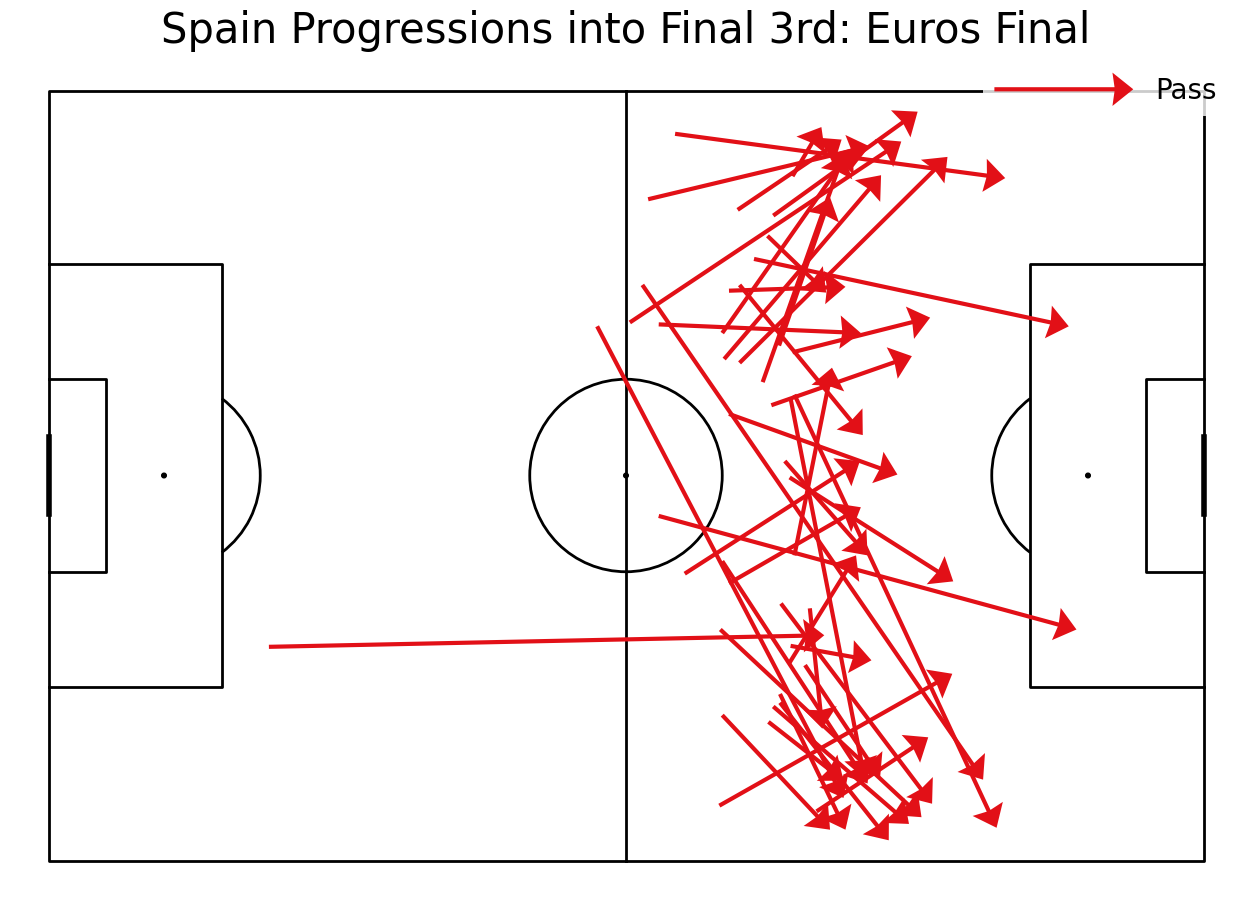

In [ ]:
#separate start and end locations from coordinates
events_df[['x', 'y']] = events_df['location'].apply(pd.Series)
events_df[['pass_end_x', 'pass_end_y']] = events_df['pass_end_location'].apply(pd.Series)
events_df[['carry_end_x', 'carry_end_y']] = events_df['carry_end_location'].apply(pd.Series)

#create a variable for the team you want to look into
team="Spain"

#filter for only matches that the focus team played in
matches_df = euro_2024_matches[(euro_2024_matches['home_team'] == team)|(euro_2024_matches['away_team'] == team)]

#filter for events done by the focus team
#filter by event type to get only passes
#filter for passes that started outside of the final third
#filter for passes that ended in the final third
#filter for completed passes
passes_df=events_df[(events_df.team==team)&(events_df.type=="Pass")&(events_df.x<80)&(events_df.pass_end_x>80)&(events_df.pass_outcome.isna())]

#Visualize for a team
pass_colour='#e21017'

#set up the pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_zorder=2, line_color='black')
fig, ax = pitch.draw(figsize=(16, 11),constrained_layout=True, tight_layout=False)
fig.set_facecolor('white')

#plot the passes
pitch.arrows(passes_df.x, passes_df.y,
passes_df.pass_end_x, passes_df.pass_end_y, width=3,
headwidth=8, headlength=5, color=pass_colour, ax=ax, zorder=2, label = "Pass")

#plot the legend
ax.legend(facecolor='white', handlelength=5, edgecolor='None', fontsize=20, loc='best')

#set title of viz
ax_title = ax.set_title(f'{team} Progressions into Final 3rd: Euros Final', fontsize=30,color='black')

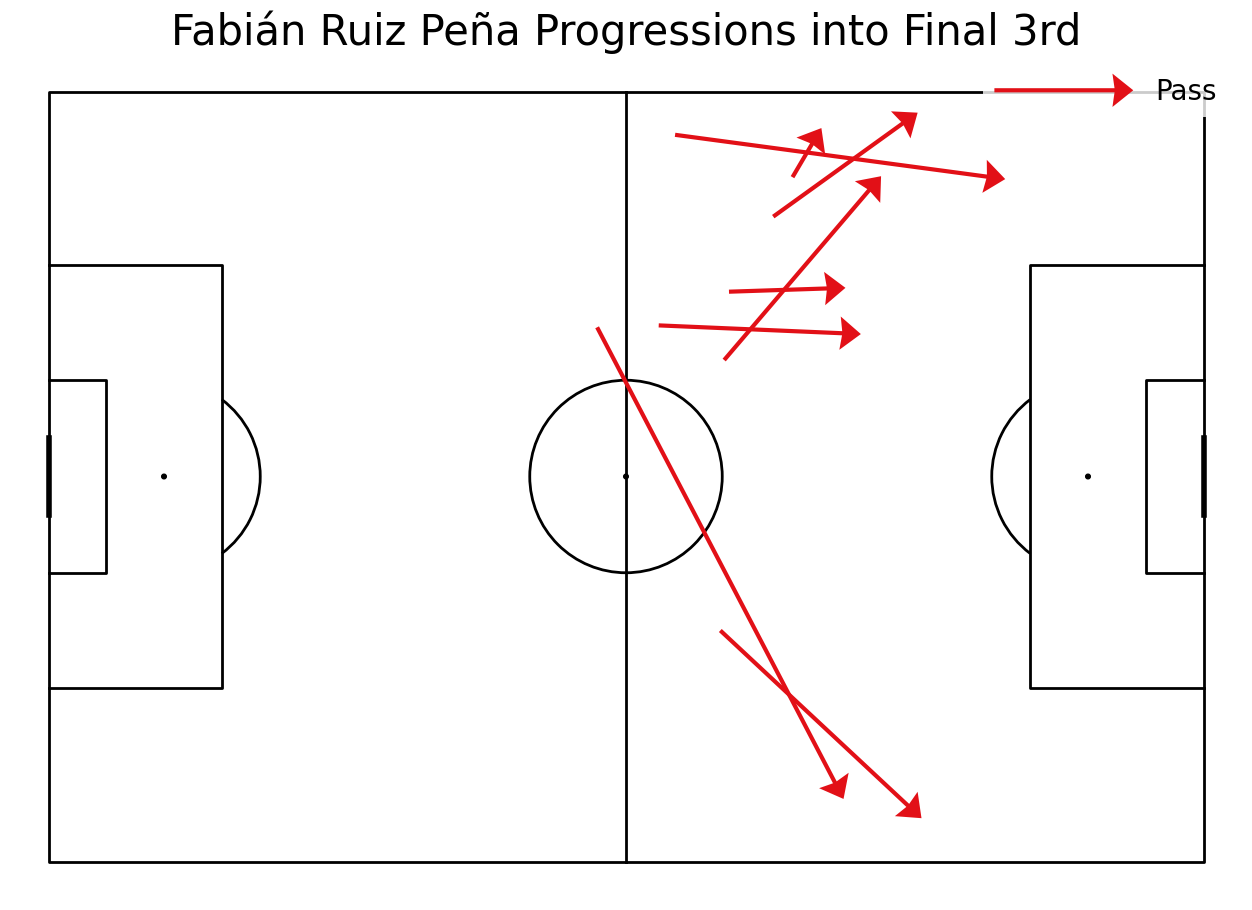

In [ ]:
#Visualize for a given player

player_name="Fabián Ruiz Peña"

player_passes=events_df[(events_df.player==player_name)&(events_df.type=="Pass")&(events_df.x<80)&(events_df.pass_end_x>80)&(events_df.pass_outcome.isna())]

pass_colour='#e21017'

#set up the pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_zorder=2, line_color='black')
fig, ax = pitch.draw(figsize=(16, 11),constrained_layout=True, tight_layout=False)
fig.set_facecolor('white')

#plot the passes
pitch.arrows(player_passes.x, player_passes.y,
player_passes.pass_end_x, player_passes.pass_end_y, width=3,
headwidth=8, headlength=5, color=pass_colour, ax=ax, zorder=2, label = "Pass")

#plot the legend
ax.legend(facecolor='white', handlelength=5, edgecolor='None', fontsize=20, loc='best')

#set title of viz
ax_title = ax.set_title(f'{player_name} Progressions into Final 3rd', fontsize=30,color='black')

In [ ]:
from statsbombpy import sb
import pandas as pd

# 1. 读取所有赛事/赛季信息
competitions = sb.competitions()

# 2. 自动识别 360 字段名
if 'match_available_360' in competitions.columns:
    col_360 = 'match_available_360'
elif 'available_360' in competitions.columns:
    col_360 = 'available_360'
else:
    raise KeyError(
        f"没有找到 360 相关字段。当前 competitions 列名为:\n{list(competitions.columns)}"
    )

# 3. 筛出有 360 数据的 competition-season
competitions_360 = competitions[competitions[col_360].notna()].copy()

print("有 360 数据的 competition-season 数量：", len(competitions_360))
print(
    competitions_360[
        ['competition_id', 'season_id', 'competition_name', 'season_name', col_360]
    ].head()
)

# 4. 逐个 competition-season 拉取 matches
all_matches = []

for _, row in competitions_360.iterrows():
    competition_id = row['competition_id']
    season_id = row['season_id']
    competition_name = row['competition_name']
    season_name = row['season_name']

    try:
        matches = sb.matches(competition_id=competition_id, season_id=season_id).copy()

        # 补充赛事信息
        matches['competition_id'] = competition_id
        matches['season_id'] = season_id
        matches['competition_name'] = competition_name
        matches['season_name'] = season_name

        all_matches.append(matches)

        print(f"完成: {competition_name} | {season_name} | {len(matches)} 场")

    except Exception as e:
        print(f"失败: competition_id={competition_id}, season_id={season_id}, error={e}")

# 5. 合并所有比赛
all_360_matches = pd.concat(all_matches, ignore_index=True)

# 6. 只保留你关心的字段
target_cols = [
    'competition_id',
    'season_id',
    'competition_name',
    'season_name',
    'match_id',
    'match_date',
    'home_team',
    'away_team',
    'home_score',
    'away_score'
]

target_cols = [c for c in target_cols if c in all_360_matches.columns]
all_360_matches = all_360_matches[target_cols].copy()

# 7. 排序
sort_cols = [c for c in ['competition_id', 'season_id', 'match_date', 'match_id'] if c in all_360_matches.columns]
all_360_matches = all_360_matches.sort_values(sort_cols).reset_index(drop=True)

# 8. 汇总每个 competition-season 的 match 数量
summary_360_matches = (
    all_360_matches
    .groupby(
        ['competition_id', 'season_id', 'competition_name', 'season_name'],
        as_index=False
    )
    .agg(match_count=('match_id', 'count'))
    .sort_values(['competition_id', 'season_id'])
    .reset_index(drop=True)
)

# 9. 输出查看
print("\n===== 所有包含 360 数据的 matches =====")
print(all_360_matches)

print("\n===== 按 competition_id + season_id 汇总 =====")
print(summary_360_matches)

有 360 数据的 competition-season 数量： 11
    competition_id  season_id competition_name season_name  \
0                9        281    1. Bundesliga   2023/2024   
29              43        106   FIFA World Cup        2022   
38              11         90          La Liga   2020/2021   
58               7        235          Ligue 1   2022/2023   
59               7        108          Ligue 1   2021/2022   

           match_available_360  
0   2025-07-06T04:26:07.636270  
29  2024-12-16T10:21:13.710934  
38  2025-01-29T18:09:18.620699  
58  2025-06-30T02:31:32.046070  
59  2025-06-15T13:02:45.341609  
完成: 1. Bundesliga | 2023/2024 | 34 场
完成: FIFA World Cup | 2022 | 64 场
完成: La Liga | 2020/2021 | 35 场
完成: Ligue 1 | 2022/2023 | 32 场
完成: Ligue 1 | 2021/2022 | 26 场
完成: Major League Soccer | 2023 | 6 场
完成: UEFA Euro | 2024 | 51 场
完成: UEFA Euro | 2020 | 51 场
完成: UEFA Women's Euro | 2025 | 31 场
完成: UEFA Women's Euro | 2022 | 31 场
完成: Women's World Cup | 2023 | 64 场

===== 所有包含 360 数据的 matches =

In [ ]:
from google.colab import sheets
import pandas as pd
import json

# 复制一份，避免改原表
all_360_matches_sheet = all_360_matches.copy()

# 把复杂类型转成字符串，避免 InteractiveSheet 报错
def make_sheet_safe(x):
    if isinstance(x, (dict, list, tuple, set)):
        return json.dumps(x, ensure_ascii=False)
    return x

all_360_matches_sheet = all_360_matches_sheet.applymap(make_sheet_safe)

# 把 datetime 也转成字符串
for col in all_360_matches_sheet.columns:
    if pd.api.types.is_datetime64_any_dtype(all_360_matches_sheet[col]):
        all_360_matches_sheet[col] = all_360_matches_sheet[col].astype(str)

# 如果有缺失值，也建议处理一下
all_360_matches_sheet = all_360_matches_sheet.fillna("")

# 输出 InteractiveSheet
sheet = sheets.InteractiveSheet(df=all_360_matches_sheet)
sheet

/tmp/ipykernel_3627/144060376.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  all_360_matches_sheet = all_360_matches_sheet.applymap(make_sheet_safe)


https://docs.google.com/spreadsheets/d/1-cwy8YPdUpTW3Sc32pguTQxCOSvyA1el5oVtnmaQzrA/edit#gid=0


In [ ]:
from statsbombpy import sb
import pandas as pd

# 确保只保留唯一比赛，避免重复统计
match_base = all_360_matches[
    ['competition_id', 'season_id', 'competition_name', 'season_name', 'match_id']
].drop_duplicates().reset_index(drop=True)

pass_stats = []

for _, row in match_base.iterrows():
    competition_id = row['competition_id']
    season_id = row['season_id']
    competition_name = row['competition_name']
    season_name = row['season_name']
    match_id = row['match_id']

    try:
        events = sb.events(match_id=match_id)

        # 兼容不同版本字段
        if 'type' in events.columns:
            pass_count = (events['type'] == 'Pass').sum()
        elif 'type_name' in events.columns:
            pass_count = (events['type_name'] == 'Pass').sum()
        else:
            raise KeyError(f"match_id={match_id} 的 events 中没有 type 或 type_name 字段")

        pass_stats.append({
            'competition_id': competition_id,
            'season_id': season_id,
            'competition_name': competition_name,
            'season_name': season_name,
            'match_id': match_id,
            'pass_count': int(pass_count)
        })

    except Exception as e:
        pass

# 每场比赛的 pass 数
match_pass_counts = pd.DataFrame(pass_stats)

# 按 competition_id + season_id 汇总
season_pass_summary = (
    match_pass_counts
    .groupby(
        ['competition_id', 'season_id', 'competition_name', 'season_name'],
        as_index=False
    )
    .agg(
        match_count=('match_id', 'count'),
        total_passes=('pass_count', 'sum')
    )
)

season_pass_summary['avg_passes_per_match'] = (
    season_pass_summary['total_passes'] / season_pass_summary['match_count']
)

season_pass_summary = season_pass_summary.sort_values(
    ['competition_id', 'season_id']
).reset_index(drop=True)

print(season_pass_summary)

    competition_id  season_id     competition_name season_name  match_count  \
0                7        108              Ligue 1   2021/2022           26   
1                7        235              Ligue 1   2022/2023           32   
2                9        281        1. Bundesliga   2023/2024           34   
3               11         90              La Liga   2020/2021           35   
4               43        106       FIFA World Cup        2022           64   
5               44        107  Major League Soccer        2023            6   
6               53        106    UEFA Women's Euro        2022           31   
7               53        315    UEFA Women's Euro        2025           31   
8               55         43            UEFA Euro        2020           51   
9               55        282            UEFA Euro        2024           51   
10              72        107    Women's World Cup        2023           64   

    total_passes  avg_passes_per_match  
0         

In [ ]:
import pandas as pd
import requests

# 1) 读取你的 Google Sheet
sheet_url = "https://docs.google.com/spreadsheets/d/1-cwy8YPdUpTW3Sc32pguTQxCOSvyA1el5oVtnmaQzrA/export?format=csv&gid=0"
sheet_df = pd.read_csv(sheet_url)

# 假设表里列名叫 match_id
sheet_ids = set(pd.to_numeric(sheet_df["match_id"], errors="coerce").dropna().astype(int))

# 2) 读取 StatsBomb open-data three-sixty 目录
api_url = "https://api.github.com/repos/statsbomb/open-data/contents/data/three-sixty"
resp = requests.get(api_url)
resp.raise_for_status()
files = resp.json()

github_ids = {
    int(f["name"].replace(".json", ""))
    for f in files
    if f["name"].endswith(".json")
}

# 3) 做差集
only_in_sheet = sorted(sheet_ids - github_ids)
only_in_github = sorted(github_ids - sheet_ids)
in_both = sorted(sheet_ids & github_ids)

print("Only in sheet:", len(only_in_sheet))
print(only_in_sheet)

print("\nOnly in GitHub three-sixty:", len(only_in_github))
print(only_in_github)

print("\nIn both:", len(in_both))

Only in sheet: 99
[3764440, 3764661, 3773369, 3773372, 3773377, 3773386, 3773387, 3773403, 3773415, 3773428, 3773457, 3773466, 3773474, 3773477, 3773497, 3773523, 3773526, 3773547, 3773552, 3773565, 3773571, 3773585, 3773586, 3773587, 3773593, 3773597, 3773625, 3773631, 3773656, 3773660, 3773661, 3773665, 3773672, 3773689, 3773695, 3802643, 3802665, 3802676, 3802683, 3802685, 3802690, 3802696, 3802699, 3802709, 3802752, 3802793, 3802795, 3802802, 3802805, 3802809, 3802818, 3802837, 3802839, 3802902, 3802904, 3802907, 3802930, 3802948, 3802983, 3802984, 3803000, 3837650, 3837659, 3837662, 3837680, 3837683, 3837695, 3837706, 3837717, 3837727, 3837747, 3837752, 3837771, 3837785, 3837818, 3837827, 3837839, 3837844, 3837859, 3837876, 3837885, 3837896, 3837902, 3837918, 3837928, 3837938, 3837947, 3837954, 3837963, 3837987, 3837998, 3838004, 3838017, 3877060, 3877072, 3877090, 3877115, 3877170, 3877194]

Only in GitHub three-sixty: 0
[]

In both: 326


In [ ]:
import pandas as pd
import requests
from io import StringIO

# ========= 1) 读取 Google Sheet =========
sheet_csv_url = "https://docs.google.com/spreadsheets/d/1-cwy8YPdUpTW3Sc32pguTQxCOSvyA1el5oVtnmaQzrA/export?format=csv&gid=0"

sheet_df = pd.read_csv(sheet_csv_url)

# 如果列名不是 match_id，请先 print(sheet_df.columns.tolist()) 看一下
sheet_match_ids = set(
    pd.to_numeric(sheet_df["match_id"], errors="coerce")
      .dropna()
      .astype(int)
      .tolist()
)

# ========= 2) 读取 StatsBomb three-sixty 下的 match_id =========
three_sixty_api = "https://api.github.com/repos/statsbomb/open-data/contents/data/three-sixty"
resp = requests.get(three_sixty_api)
resp.raise_for_status()

three_sixty_files = resp.json()
three_sixty_match_ids = set(
    int(f["name"].replace(".json", ""))
    for f in three_sixty_files
    if f["name"].endswith(".json")
)

# ========= 3) 读取 competitions.json =========
competitions_url = "https://raw.githubusercontent.com/statsbomb/open-data/master/data/competitions.json"
competitions = requests.get(competitions_url).json()

competitions_df = pd.DataFrame(competitions)

# 只保留需要的列
competitions_meta = competitions_df[[
    "competition_id", "season_id", "competition_name", "season_name"
]].drop_duplicates()

# ========= 4) 建立 match_id -> competition/season 映射 =========
match_meta_rows = []

for _, row in competitions_meta.iterrows():
    competition_id = row["competition_id"]
    season_id = row["season_id"]
    competition_name = row["competition_name"]
    season_name = row["season_name"]

    matches_url = f"https://raw.githubusercontent.com/statsbomb/open-data/master/data/matches/{competition_id}/{season_id}.json"
    r = requests.get(matches_url)

    # 有些路径可能不存在，跳过
    if r.status_code != 200:
        continue

    matches = r.json()
    if not isinstance(matches, list):
        continue

    for m in matches:
        match_id = m.get("match_id")
        if match_id is not None:
            match_meta_rows.append({
                "match_id": int(match_id),
                "competition_id": int(competition_id),
                "season_id": int(season_id),
                "competition_name": competition_name,
                "season_name": season_name,
                "home_team": m.get("home_team", {}).get("home_team_name"),
                "away_team": m.get("away_team", {}).get("away_team_name"),
                "match_date": m.get("match_date")
            })

match_meta_df = pd.DataFrame(match_meta_rows).drop_duplicates(subset=["match_id"])

# ========= 5) 做差集 =========
only_in_sheet = sorted(sheet_match_ids - three_sixty_match_ids)
only_in_three_sixty = sorted(three_sixty_match_ids - sheet_match_ids)
in_both = sorted(sheet_match_ids & three_sixty_match_ids)

# ========= 6) 输出带 competition / season 的结果 =========
only_in_sheet_df = (
    pd.DataFrame({"match_id": only_in_sheet})
    .merge(match_meta_df, on="match_id", how="left")
    .sort_values(["competition_id", "season_id", "match_id"])
    .reset_index(drop=True)
)

only_in_three_sixty_df = (
    pd.DataFrame({"match_id": only_in_three_sixty})
    .merge(match_meta_df, on="match_id", how="left")
    .sort_values(["competition_id", "season_id", "match_id"])
    .reset_index(drop=True)
)

in_both_df = (
    pd.DataFrame({"match_id": in_both})
    .merge(match_meta_df, on="match_id", how="left")
    .sort_values(["competition_id", "season_id", "match_id"])
    .reset_index(drop=True)
)

# ========= 7) 查看结果 =========
print("只在 Google Sheet 中有，不在 three-sixty 中的 match 数量：", len(only_in_sheet_df))
display(only_in_sheet_df)

print("只在 three-sixty 中有，不在 Google Sheet 中的 match 数量：", len(only_in_three_sixty_df))
display(only_in_three_sixty_df)

print("两边都有的 match 数量：", len(in_both_df))
display(in_both_df)

只在 Google Sheet 中有，不在 three-sixty 中的 match 数量： 99


,match_id,competition_id,season_id,competition_name,season_name,home_team,away_team,match_date
0,3802643,7,108,Ligue 1,2021/2022,Strasbourg,Paris Saint-Germain,2022-04-29
1,3802665,7,108,Ligue 1,2021/2022,Montpellier,Paris Saint-Germain,2022-05-14
2,3802676,7,108,Ligue 1,2021/2022,Paris Saint-Germain,Lens,2022-04-23
3,3802683,7,108,Ligue 1,2021/2022,Paris Saint-Germain,AS Monaco,2021-12-12
4,3802685,7,108,Ligue 1,2021/2022,Lens,Paris Saint-Germain,2021-12-04
...,...,...,...,...,...,...,...,...
94,3877072,44,107,Major League Soccer,2023,Inter Miami,Nashville SC,2023-08-31
95,3877090,44,107,Major League Soccer,2023,LAFC,Inter Miami,2023-09-04
96,3877115,44,107,Major League Soccer,2023,Inter Miami,Toronto FC,2023-09-21
97,3877170,44,107,Major League Soccer,2023,Inter Miami,Cincinnati,2023-10-08


只在 three-sixty 中有，不在 Google Sheet 中的 match 数量： 0


,match_id,competition_id,season_id,competition_name,season_name,home_team,away_team,match_date


两边都有的 match 数量： 326


,match_id,competition_id,season_id,competition_name,season_name,home_team,away_team,match_date
0,3895052,9,281,1. Bundesliga,2023/2024,Bayer Leverkusen,RB Leipzig,2023-08-19
1,3895060,9,281,1. Bundesliga,2023/2024,Borussia Mönchengladbach,Bayer Leverkusen,2023-08-26
2,3895067,9,281,1. Bundesliga,2023/2024,Bayer Leverkusen,Darmstadt 98,2023-09-02
3,3895074,9,281,1. Bundesliga,2023/2024,Bayern Munich,Bayer Leverkusen,2023-09-15
4,3895086,9,281,1. Bundesliga,2023/2024,Bayer Leverkusen,FC Heidenheim,2023-09-24
...,...,...,...,...,...,...,...,...
321,3902968,72,107,Women's World Cup,2023,Australia Women's,France Women's,2023-08-12
322,3904628,72,107,Women's World Cup,2023,Spain Women's,Sweden Women's,2023-08-15
323,3904629,72,107,Women's World Cup,2023,Australia Women's,England Women's,2023-08-16
324,3906389,72,107,Women's World Cup,2023,Sweden Women's,Australia Women's,2023-08-19


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=in_both_df)

https://docs.google.com/spreadsheets/d/1_1yHgP4MLnDra98lSqLTM8OhmGIqYIUwOgROJHuOOh4/edit#gid=0


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=only_in_sheet_df)

https://docs.google.com/spreadsheets/d/1o94YEA9zkXjY6z2fmLbo-eaPDuMppg0zhQ8L9SxCtCw/edit#gid=0
